In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
flights = pd.read_csv("flights_cleaned.csv")
satisfaction = pd.read_csv("satisfaction_cleaned.csv")

In [3]:
flights.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,dep_hour
0,2024,4,18,4,4/18/2024,MQ,3535,DFW,"Dallas/Fort Worth, TX",Texas,...,151,144.0,119.0,835,0,0,0,0,0,10
1,2024,1,1,1,1/1/2024,AA,148,CLT,"Charlotte, NC",North Carolina,...,286,273.0,253.0,1773,0,0,0,0,0,16
2,2024,12,12,4,12/12/2024,9E,5440,CHA,"Chattanooga, TN",Tennessee,...,59,50.0,29.0,106,0,0,0,0,0,9
3,2024,4,8,1,4/8/2024,WN,1971,OMA,"Omaha, NE",Nebraska,...,180,177.0,163.0,1099,0,0,0,0,0,13
4,2024,2,16,5,2/16/2024,WN,862,BWI,"Baltimore, MD",Maryland,...,90,96.0,76.0,399,0,0,0,0,0,13


In [4]:
satisfaction.head()

,column1,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure_Arrival_time_convenient,...,Inflight_entertainment,On_board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,7054,126465,Female,Loyal Customer,51,Business travel,Business,1972,1,1,...,4,4,4,4,5,4,4,0,0.0,satisfied
1,7055,66104,Male,Loyal Customer,59,Business travel,Business,2082,2,2,...,5,5,5,5,5,5,5,0,0.0,satisfied
2,7056,53134,Female,disloyal Customer,35,Business travel,Eco,413,3,4,...,1,4,5,4,3,3,1,0,0.0,neutral or dissatisfied
3,7057,82331,Female,Loyal Customer,11,Personal Travel,Eco,456,3,4,...,1,4,4,5,4,5,1,0,0.0,neutral or dissatisfied
4,7058,70324,Male,Loyal Customer,59,Business travel,Business,986,1,1,...,5,5,5,5,3,5,3,0,2.0,satisfied


In [5]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9884 entries, 0 to 9883
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 9884 non-null   int64  
 1   month                9884 non-null   int64  
 2   day_of_month         9884 non-null   int64  
 3   day_of_week          9884 non-null   int64  
 4   fl_date              9884 non-null   object 
 5   op_unique_carrier    9884 non-null   object 
 6   op_carrier_fl_num    9884 non-null   int64  
 7   origin               9884 non-null   object 
 8   origin_city_name     9884 non-null   object 
 9   origin_state_nm      9884 non-null   object 
 10  dest                 9884 non-null   object 
 11  dest_city_name       9884 non-null   object 
 12  dest_state_nm        9884 non-null   object 
 13  crs_dep_time         9884 non-null   int64  
 14  dep_time             9884 non-null   int64  
 15  dep_delay            9884 non-null   i

In [6]:
satisfaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   column1                            103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer_Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type_of_Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight_Distance                    103904 non-null  int64  
 8   Inflight_wifi_service              103904 non-null  int64  
 9   Departure_Arrival_time_convenient  103904 non-null  int64  
 10  Ease_of_Online_booking             103904 non-null  int64  
 11  Gate_location                      1039

In [7]:
flights['dep_delay'].describe()

count    9884.000000
mean       16.291785
std        52.471765
min         0.000000
25%         0.000000
50%         0.000000
75%         9.250000
max      2011.000000
Name: dep_delay, dtype: float64

“The dataset shows variability in departure delays, indicating inconsistent operational performance.”

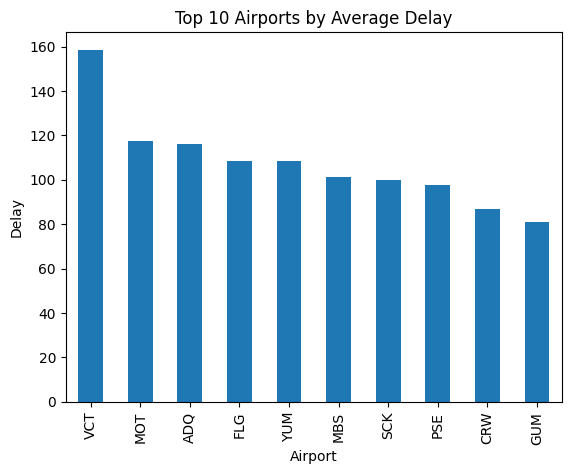

In [8]:
flights.groupby('origin')['dep_delay'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Airports by Average Delay")
plt.xlabel("Airport")
plt.ylabel("Delay")
plt.show()

“Certain airports consistently experience higher delays, indicating operational bottlenecks.”

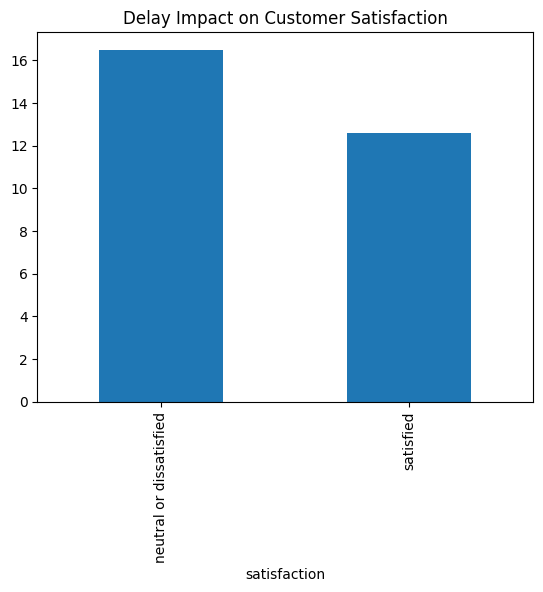

In [10]:
satisfaction.groupby('satisfaction')['Departure_Delay_in_Minutes'].mean().plot(kind='bar')
plt.title("Delay Impact on Customer Satisfaction")
plt.show()

“Higher delays are associated with lower customer satisfaction levels.”

In [12]:
satisfaction.groupby('Class')['satisfaction'].value_counts()

Class     satisfaction           
Business  satisfied                  34480
          neutral or dissatisfied    15185
Eco       neutral or dissatisfied    38044
          satisfied                   8701
Eco Plus  neutral or dissatisfied     5650
          satisfied                   1844
Name: count, dtype: int64

“Passenger class impacts satisfaction levels, with premium classes showing higher satisfaction.”

In [45]:
df = flights.copy()
df.to_csv("final_airline_data.csv", index=False)